In [103]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.stats

In [89]:
from rom_decadal_lib import *

In [90]:
def calc_model_histogram(
                         model,
                         T_variable = 'nino34',
                         h_variable = 'h_eq',
                        ):
    
                         
    indices = xr.open_dataset('indices/'+model+'_SMILE_indices.nc').isel(time=slice(120,None)).sel(time=slice(None,'2025'))
    if model == 'CESM1-CAM5':
        indices = indices.isel({'M':np.array([False if x==32 else True for x in range(40)])})
    T = declim_detrend_quadratic(indices[T_variable])
    h = declim_detrend_quadratic(indices[h_variable])

    full_y = xr.concat((T,h),dim='v').assign_coords({'v':np.array(('T','h'))})
    full_dy = full_y.diff('time',label='lower') # this is the dy at the time it starts from

    full_y  =  full_y.coarsen(time=120,boundary='trim').construct(time=('decade','time'))
    full_dy = full_dy.coarsen(time=120,boundary='trim').construct(time=('decade','time'))
    
    bwj = calc_BWJ(full_y,full_dy)
    bj = np.real(bwj)
    wk = np.imag(bwj)
    
    return bj, wk
 
def plot_model_histogram(axs, model, T_variable='nino34',h_variable='h_eq'):
    bj, wk = calc_model_histogram(model, T_variable, h_variable)
    
    plt.sca(axs[0])
    plt.hist(bj.data.flatten(),color=BJC,bins=re_bins,density=True)
    plt.yticks([])
    
    plt.sca(axs[1])
    plt.hist(wk.data.flatten(),color=WKC,bins=im_bins,density=True)
    plt.yticks([])

In [91]:
def calc_pseudorun_histogram(full_y
                             
                        ):

    full_dy = full_y.diff('time',label='lower') # this is the dy at the time it starts from

    full_y  = full_y.coarsen(time=120,boundary='trim').construct(time=('decade','time'))
    full_dy = full_dy.coarsen(time=120,boundary='trim').construct(time=('decade','time'))
    
    bwj = calc_BWJ(full_y,full_dy)
    bj = np.real(bwj)
    wk = np.imag(bwj)
    
    return bj, wk

def plot_pseudorun_histogram(axs, full_y, **line_kwargs):
    bj, wk = calc_pseudorun_histogram(full_y)
    
    plt.sca(axs[0])
    plot_edge_only_histogram(bj,bins=re_bins,density=True,**line_kwargs)#linewidth=1.5)

    plt.yticks([])
    
    plt.sca(axs[1])
    plot_edge_only_histogram(wk,bins=im_bins,density=True,**line_kwargs)
    plt.yticks([])

In [92]:
def plot_model_cumulative(axs, model, T_variable='nino34',h_variable='h_eq'):
    bj, wk = calc_model_histogram(model, T_variable, h_variable)
    

    plt.sca(axs[0])
    cumulative_bj = sorted(bj.stack({'ts':('M','decade')}).data)
    plt.plot(cumulative_bj,np.linspace(0,1,len(cumulative_bj)))
#     plt.hist(bj.data.flatten(),color=BJC,bins=re_bins,density=True)
    plt.yticks([])
    
    plt.sca(axs[1])
    cumulative_wk = sorted(wk.stack({'ts':('M','decade')}).data)
    plt.plot(cumulative_wk,np.linspace(0,1,len(cumulative_wk)))
    plt.yticks([])
    
def plot_pseudorun_cumulative(axs, full_y, **line_kwargs):
    bj, wk = calc_pseudorun_histogram(full_y)
    
    plt.sca(axs[0])
    cumulative_bj = sorted(bj.stack({'ts':('M0','decade')}).data)
    plt.plot(cumulative_bj,np.linspace(0,1,len(cumulative_bj)),**line_kwargs)
#     plt.hist(bj.data.flatten(),color=BJC,bins=re_bins,density=True)
    plt.yticks([])
    
    plt.sca(axs[1])
    cumulative_wk = sorted(wk.stack({'ts':('M0','decade')}).data)
    plt.plot(cumulative_wk,np.linspace(0,1,len(cumulative_wk)),**line_kwargs)
    plt.yticks([])

(0.06, 0.25)

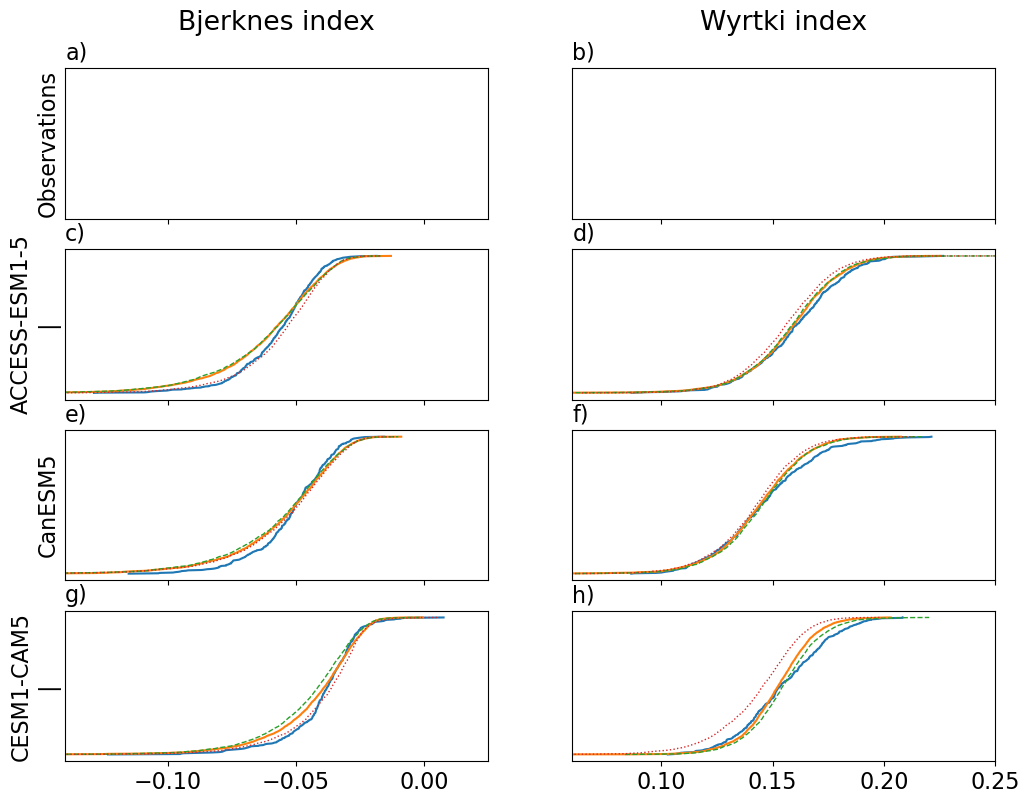

In [100]:
n_bins = 25
re_bins = np.linspace(-0.2,0,n_bins)
im_bins = np.linspace(0,0.2,n_bins)

fig, axs = plt.subplots(4,2,figsize=(12,9),sharex='col',sharey=True)


model_set =('ACCESS-ESM1-5','CanESM5','CESM1-CAM5')
for i, model in enumerate(model_set):
    
    plot_model_cumulative(axs[i+1,:],model,)
    plot_pseudorun_cumulative(axs[i+1,:],
                             xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_linear_2D_pSMILE_qdt.nc').pseudo_run,
                             linewidth=1.5,
                            )
    plot_pseudorun_cumulative(axs[i+1,:],
                         xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_quadT_pSMILE_qdt.nc').pseudo_run,
                         linewidth=1,
                        linestyle='dashed',
                        )
    plot_pseudorun_cumulative(axs[i+1,:],
                         xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_lookup_table_pSMILE_qdt.nc').pseudo_run,
                         linewidth=1,
                        linestyle='dotted',
                        )
    

axs[0,0].set_title('Bjerknes index\n ')
axs[0,0].set_ylabel('Observations')
axs[0,1].set_title('Wyrtki index\n ')
for i,model in enumerate(model_set):
    if i%2==0:
        axs[i+1,0].set_ylabel(model+'\n|')
    else:
        axs[i+1,0].set_ylabel(model)

letters = 'abcdefghijklmnop'
for i in range(2):
    for j in range(4):
        plt.sca(axs[j,i])
        plt.title(letters[j*2+i]+')',loc='left',fontsize=16)

axs[0,0].set_xlim((-0.14,0.025))
axs[0,1].set_xlim((0.06,0.25))


In [94]:
import seaborn
def plot_model_pretty(axs, model, T_variable='nino34',h_variable='h_eq'):
    bj, wk = calc_model_histogram(model, T_variable, h_variable)

    data = bj.stack({'ts':('M','decade')}).data
    seaborn.kdeplot(data,color=BJC,fill=True,alpha=1,ax=axs[0])

    data = wk.stack({'ts':('M','decade')}).data
    seaborn.kdeplot(data,color=WKC,fill=True,alpha=1,ax=axs[1])
    
def plot_pseudorun_pretty(axs, full_y, **line_kwargs):
    bj, wk = calc_pseudorun_histogram(full_y)
    
    data = bj.stack({'ts':('M0','decade')}).data
    seaborn.kdeplot(data,color='k',**line_kwargs,ax=axs[0])
    
    plt.sca(axs[1])
    data = wk.stack({'ts':('M0','decade')}).data
    seaborn.kdeplot(data,color='k',**line_kwargs,ax=axs[1])

0 ACCESS-ESM1-5
<bound method _AxesBase.get_ylabel of <Axes: ylabel='ACCESS-ESM1-5\n|'>>
1 CanESM5
<bound method _AxesBase.get_ylabel of <Axes: ylabel='CanESM5'>>
2 CESM1-CAM5
<bound method _AxesBase.get_ylabel of <Axes: ylabel='CESM1-CAM5\n|'>>


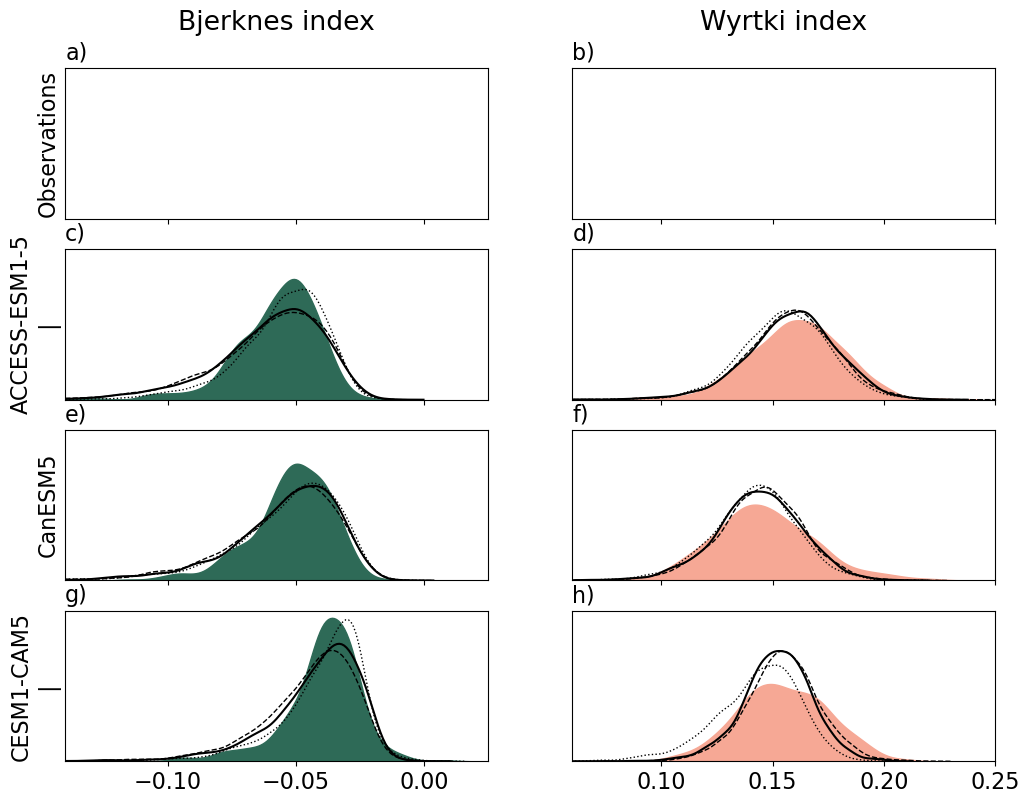

In [95]:
n_bins = 25
re_bins = np.linspace(-0.2,0,n_bins)
im_bins = np.linspace(0,0.2,n_bins)

fig, axs = plt.subplots(4,2,figsize=(12,9),sharex='col',sharey=True)


model_set =('ACCESS-ESM1-5','CanESM5','CESM1-CAM5')
for i, model in enumerate(model_set):
    pass
    plot_model_pretty(axs[i+1,:],model,)
    plot_pseudorun_pretty(axs[i+1,:],
                     xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_linear_2D_pSMILE_qdt.nc').pseudo_run,
                     linewidth=1.5,
                    )

    plot_pseudorun_pretty(axs[i+1,:],
                         xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_quadT_pSMILE_qdt.nc').pseudo_run,
                         linewidth=1,
                        linestyle='dashed',
                        )
    plot_pseudorun_pretty(axs[i+1,:],
                         xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_lookup_table_pSMILE_qdt.nc').pseudo_run,
                         linewidth=1,
                        linestyle='dotted',
                        )



axs[0,0].set_title('Bjerknes index\n ')
axs[0,0].set_ylabel('Observations')
axs[0,1].set_title('Wyrtki index\n ')

axs[0,0].set_xlim((-0.14,0.025))
axs[0,1].set_xlim((0.06,0.25))


for i,model in enumerate(model_set):
    if i%2==0:
        axs[i+1,0].set_ylabel(model+'\n|')
    else:
        axs[i+1,0].set_ylabel(model)
    print(i,model)
    print(axs[i+1,0].get_ylabel)
    axs[i+1,0].set_yticks([])

letters = 'abcdefghijklmnop'
for i in range(2):
    for j in range(4):
        plt.sca(axs[j,i])
        plt.title(letters[j*2+i]+')',loc='left',fontsize=16)

0 CESM2
<bound method _AxesBase.get_ylabel of <Axes: title={'center': 'Bjerknes index\n '}, ylabel='CESM2\n|'>>
1 IPSL-CM6A-LR
<bound method _AxesBase.get_ylabel of <Axes: ylabel='IPSL-CM6A-LR'>>
2 MIROC6
<bound method _AxesBase.get_ylabel of <Axes: ylabel='MIROC6\n|'>>


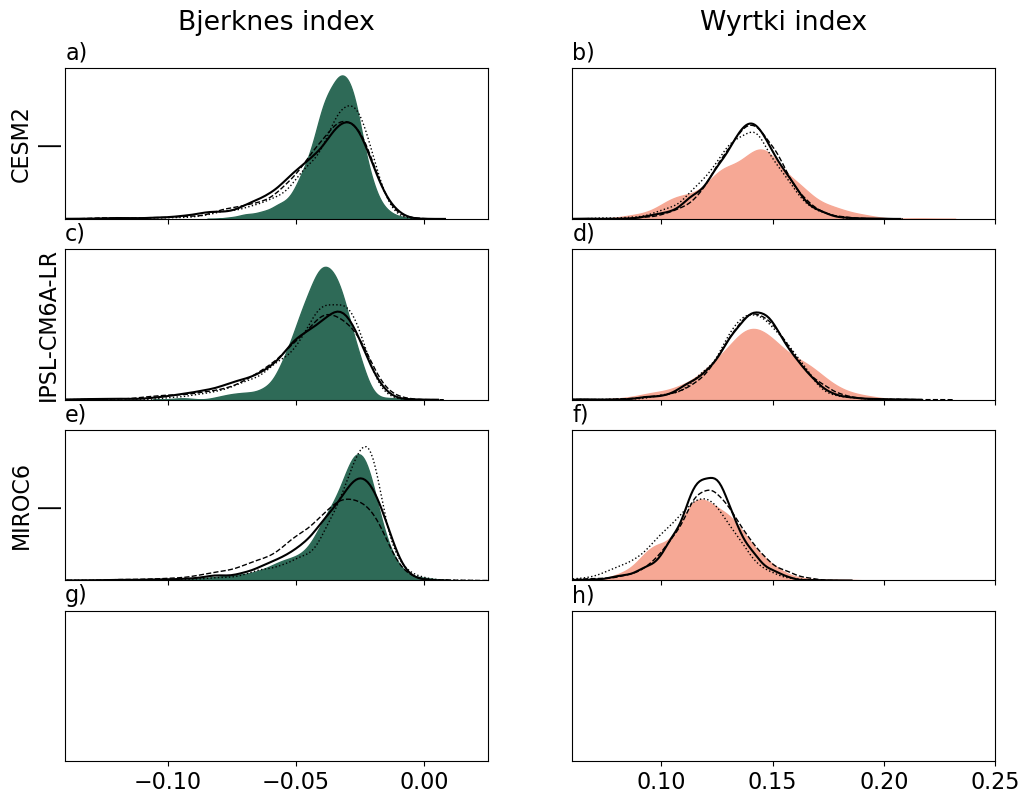

In [99]:
n_bins = 25
re_bins = np.linspace(-0.2,0,n_bins)
im_bins = np.linspace(0,0.2,n_bins)

fig, axs = plt.subplots(4,2,figsize=(12,9),sharex='col',sharey=True)


model_set =('CESM2','IPSL-CM6A-LR','MIROC6')
for i, model in enumerate(model_set):
    pass
    plot_model_pretty(axs[i,:],model,)
    plot_pseudorun_pretty(axs[i,:],
                     xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_linear_2D_pSMILE_qdt.nc').pseudo_run,
                     linewidth=1.5,
                    )

    plot_pseudorun_pretty(axs[i,:],
                         xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_quadT_pSMILE_qdt.nc').pseudo_run,
                         linewidth=1,
                        linestyle='dashed',
                        )
    plot_pseudorun_pretty(axs[i,:],
                         xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_lookup_table_pSMILE_qdt.nc').pseudo_run,
                         linewidth=1,
                        linestyle='dotted',
                        )



axs[0,0].set_title('Bjerknes index\n ')
axs[0,0].set_ylabel('Observations')
axs[0,1].set_title('Wyrtki index\n ')

axs[0,0].set_xlim((-0.14,0.025))
axs[0,1].set_xlim((0.06,0.25))


for i,model in enumerate(model_set):
    if i%2==0:
        axs[i,0].set_ylabel(model+'\n|')
    else:
        axs[i,0].set_ylabel(model)
    print(i,model)
    print(axs[i,0].get_ylabel)
    axs[i,0].set_yticks([])

letters = 'abcdefghijklmnop'
for i in range(2):
    for j in range(4):
        plt.sca(axs[j,i])
        plt.title(letters[j*2+i]+')',loc='left',fontsize=16)

In [121]:
model_set =('ACCESS-ESM1-5','CanESM5','CESM1-CAM5','CESM2','IPSL-CM6A-LR','MIROC6')
for i, model in enumerate(model_set):
    mbj, mwk = [x.stack({'ts':('M','decade')}) for x in calc_model_histogram(model)]

    for romshape in ('linear_2D','quadT','lookup_table'):
        data = xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_'+romshape+'_pSMILE_qdt.nc').pseudo_run
        rbj, rwk = [x.stack({'ts':('M0','decade')}) for x in calc_pseudorun_histogram(data)]
        
        stat, pvalue, *_ = scipy.stats.kstest(rbj, mbj)
        print(model, romshape, round(stat,2), round(pvalue,5))
        stat, pvalue, *_ = scipy.stats.kstest(rwk, mwk)
        print(model, romshape, round(stat,2), round(pvalue,5))
        
    print('----')
        
        
        

ACCESS-ESM1-5 linear_2D 0.09 0.00033
ACCESS-ESM1-5 linear_2D 0.07 0.02105
ACCESS-ESM1-5 quadT 0.1 4e-05
ACCESS-ESM1-5 quadT 0.07 0.01101
ACCESS-ESM1-5 lookup_table 0.09 0.00025
ACCESS-ESM1-5 lookup_table 0.11 0.0
----
CanESM5 linear_2D 0.09 0.00786
CanESM5 linear_2D 0.08 0.0346
CanESM5 quadT 0.11 0.00096
CanESM5 quadT 0.08 0.0265
CanESM5 lookup_table 0.08 0.02245
CanESM5 lookup_table 0.11 0.0009
----
CESM1-CAM5 linear_2D 0.12 0.00017
CESM1-CAM5 linear_2D 0.14 1e-05
CESM1-CAM5 quadT 0.17 0.0
CESM1-CAM5 quadT 0.09 0.01281
CESM1-CAM5 lookup_table 0.09 0.01882
CESM1-CAM5 lookup_table 0.23 0.0
----
CESM2 linear_2D 0.16 0.0
CESM2 linear_2D 0.09 3e-05
CESM2 quadT 0.14 0.0
CESM2 quadT 0.09 0.0001
CESM2 lookup_table 0.1 0.0
CESM2 lookup_table 0.13 0.0
----
IPSL-CM6A-LR linear_2D 0.17 0.0
IPSL-CM6A-LR linear_2D 0.08 0.00557
IPSL-CM6A-LR quadT 0.16 0.0
IPSL-CM6A-LR quadT 0.07 0.02585
IPSL-CM6A-LR lookup_table 0.12 1e-05
IPSL-CM6A-LR lookup_table 0.08 0.00497
----
MIROC6 linear_2D 0.07 0.011
MIROC

(array([  1.,   5.,   6.,  16.,  35.,  68., 107.,  88.,  45.,   4.]),
 array([-0.11521032, -0.10523162, -0.09525293, -0.08527424, -0.07529555,
        -0.06531685, -0.05533816, -0.04535947, -0.03538077, -0.02540208,
        -0.01542339]),
 <BarContainer object of 10 artists>)

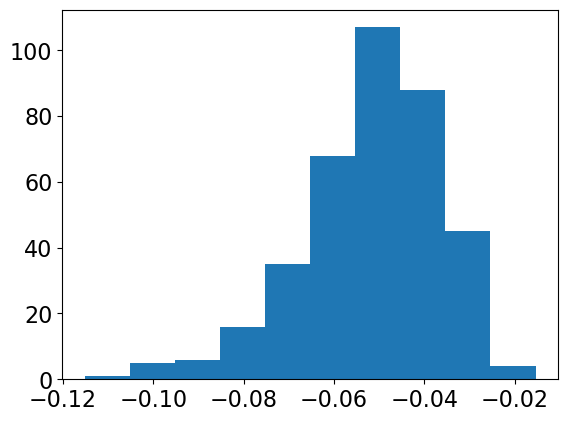

In [120]:
plt.hist(calc_model_histogram('CanESM5')[0].stack({'ts':('M','decade')}))
                                               